# Comparing samplers

Fit a Gaussian location-scale model to motorcycle crash-test measurements,
then compare IWLS/Gibbs with NUTS/Gibbs. Both strategies target the **same
posterior**. Their effective sample sizes and agreement on fitted curves help
assess this run; they do not establish a universal ranking of samplers.

This example assumes {doc}`01c-transform` and {doc}`01d-gibbs-sampling`.
[Liesel-GAM](https://liesel-gam.readthedocs.io/latest/) supplies centered
P-splines and their smoothing priors; the code below uses version 0.2.4.
For the general model-building workflow, see
{doc}`../notebooks/12-model-predictions`.

## Load the measurements

The 133 observations in `MASS::mcycle` record head acceleration in g at times
in milliseconds after impact. Repeated times are distinct measurements and
remain in the likelihood. The model treats measurements as conditionally
independent; it does not model dependence between measurements from a crash.

Download {download}`the bundled CSV <data/mcycle.csv>` beside this notebook into a `data`
folder. It is an unmodified numeric export from MASS 7.3-65, so executing the
example needs neither R nor a network connection. The
{doc}`data provenance and license <data/mcycle-provenance>` give its source and
redistribution terms.

In [1]:
from pathlib import Path

import jax
import jax.numpy as jnp
import liesel_gam as gam
import numpy as np
import pandas as pd
import plotnine as p9
import tensorflow_probability.substrates.jax.distributions as tfd

import liesel.goose as gs
import liesel.model as lsl

# Keep spline geometry and likelihood calculations in double precision.
jax.config.update("jax_enable_x64", True)

mcycle = pd.read_csv(Path("data/mcycle.csv"))
mcycle["response"] = mcycle["accel"] / 100.0

In [2]:
mcycle.head()

,times,accel,response
0,2.4,0.0,0.000
1,2.6,-1.3,-0.013
2,3.2,-2.7,-0.027
3,3.6,0.0,0.000
4,4.0,-2.7,-0.027


(data)=

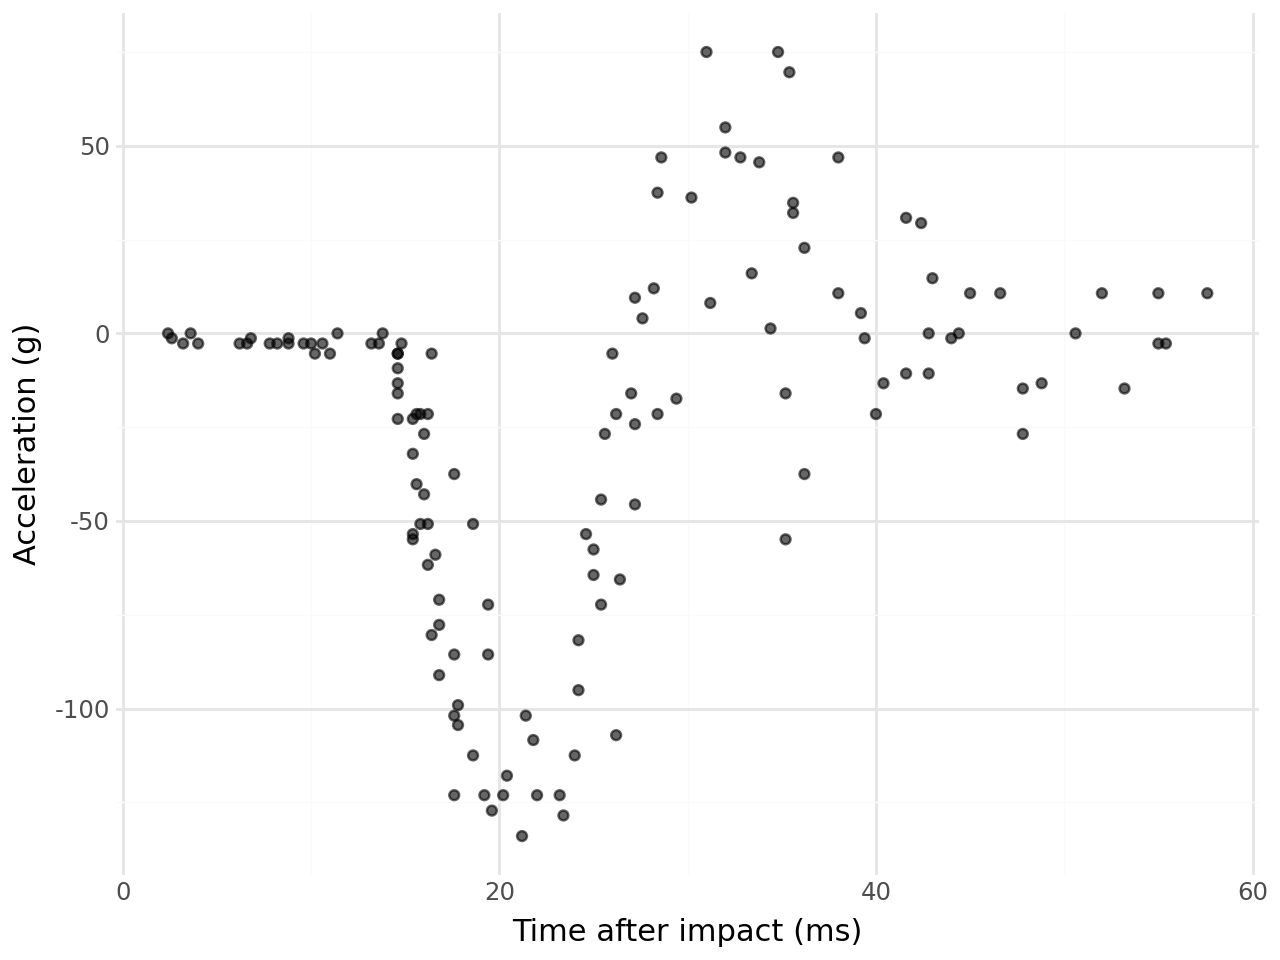

In [3]:
(
    p9.ggplot(mcycle, p9.aes("times", "accel"))
    + p9.geom_point(alpha=0.6)
    + p9.labs(x="Time after impact (ms)", y="Acceleration (g)")
    + p9.theme_minimal()
)

## Define one posterior

We model acceleration in units of 100 g to keep coefficients near unit scale.
Both the mean and log standard deviation have a centered smooth and an
intercept. The intercept priors are normal with standard deviations 2 and 1,
respectively. Each spline uses the default second-order difference penalty
and its own smoothing variance $\tau^2\sim\operatorname{InverseGamma}(1,0.005)$.
This variance controls smoothness; it is distinct from the response variance
$\sigma(t)^2$.

We keep 64-bit arithmetic enabled in this notebook and construct the model
with `to_float32=False`: the sharply different response spreads make numerical
precision relevant for these spline calculations.

The mean uses 20 basis functions and log standard deviation uses 10. These are
modeling choices shared by both samplers. We keep the centered B-spline
representation with `diagonal_penalty=False`; diagonalizing the penalty would
rescale the coefficient directions substantially in this example. Both samplers
use the same basis and penalty. Basis-size and prior sensitivity
would be separate checks in an application.

In [4]:
registry = gam.PandasRegistry(mcycle)
mean_builder = gam.TermBuilder(registry, prefix_names_by="mean.")
scale_builder = gam.TermBuilder(registry, prefix_names_by="scale.")

# Intercepts start at a constant fit to the rescaled observations.
mean_intercept = lsl.Var.new_param(
    float(mcycle["response"].mean()),
    dist=lsl.Dist(tfd.Normal, loc=0.0, scale=2.0),
    name="mean_intercept",
    inference=gs.MCMCSpec(gs.IWLSKernel.untuned),
)

scale_intercept = lsl.Var.new_param(
    float(np.log(mcycle["response"].std())),
    dist=lsl.Dist(tfd.Normal, loc=0.0, scale=1.0),
    name="scale_intercept",
    inference=gs.MCMCSpec(gs.IWLSKernel.untuned),
)

mu = gam.AdditivePredictor("mu", intercept=mean_intercept)
sigma = gam.AdditivePredictor(
    "sigma",
    inv_link=jnp.exp,
    intercept=scale_intercept,
)

mean_smooth = mean_builder.ps("times", k=20, diagonal_penalty=False)
scale_smooth = scale_builder.ps("times", k=10, diagonal_penalty=False)
mu += mean_smooth
sigma += scale_smooth

y = lsl.Var.new_obs(
    mcycle["response"].to_numpy(),
    dist=lsl.Dist(tfd.Normal, loc=mu, scale=sigma),
    name="y",
)
model = lsl.Model(y, to_float32=False)

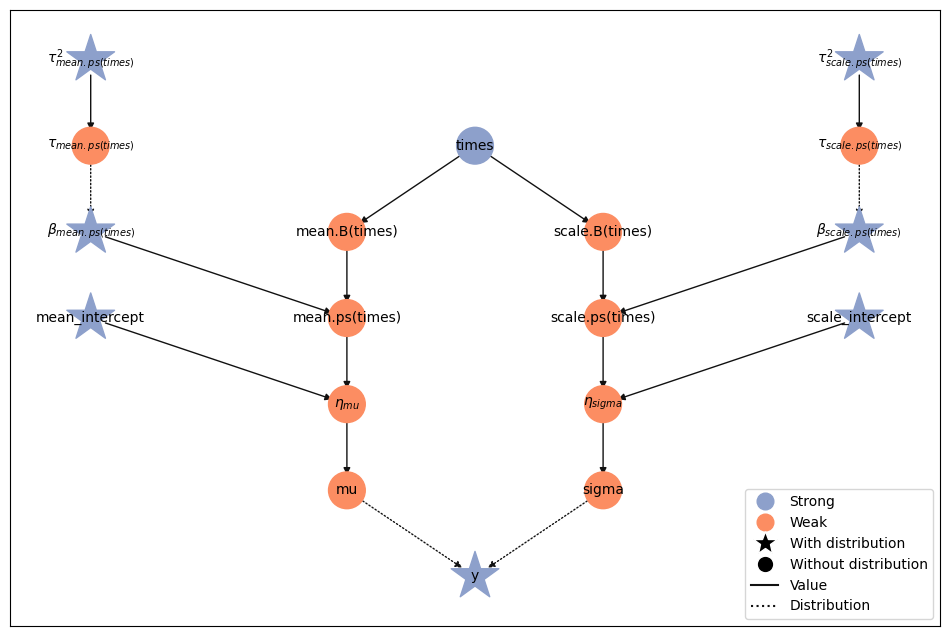

In [5]:
model.plot(width=12, height=8)

Zero initial spline coefficients give a constant mean and positive standard
deviation. This is a finite starting point, not a fitted curve. Check it before
launching chains. For a conditional mode start, optimize coefficients while
holding smoothing variances fixed, then keep their Gibbs updates for MCMC.
See {doc}`../../goose-initialization` for the general initialization workflow.

In [6]:
pd.Series(
    {
        "initial log density": float(model.log_prob),
        "initial mean (g)": float(mean_intercept.value) * 100.0,
        "initial standard deviation (g)": float(sigma.value[0]) * 100.0,
    },
).round(3)

initial log density              -104.901
initial mean (g)                  -25.546
initial standard deviation (g)     48.322
dtype: float64

## Metropolis-in-Gibbs

The term builders attach untuned IWLS coefficient updates and exact Gibbs
updates for the smoothing variances. The two intercepts also use IWLS. Add
small coefficient perturbations and positive variance perturbations so the
chains start at different states. The jitter distributions also use double
precision so those starts retain the model's dtype. The default untuned kernels
need burn-in but no adaptation phase.

In [7]:
iwls_model = model.copy()
variance_names = [
    mean_smooth.scale.value_node[0].name,
    scale_smooth.scale.value_node[0].name,
]

coefficient_jitter = tfd.Normal(
    loc=jnp.float64(0.0),
    scale=jnp.float64(0.02),
)

variance_jitter = tfd.LogNormal(
    loc=jnp.float64(0.0),
    scale=jnp.float64(0.1),
)

for name, parameter in iwls_model.parameters.items():
    if name in variance_names:
        parameter.inference.jitter_dist = variance_jitter
        parameter.inference.jitter_method = "multiplicative"
    else:
        parameter.inference.jitter_dist = coefficient_jitter

In [8]:
iwls_results = gs.LieselMCMC(iwls_model).run_for_epochs(
    seed=2026,
    num_chains=4,
    adaptation=0,
    burnin=1000,
    posterior=2000,
    show_progress=False,
)
iwls_summary = gs.Summary(iwls_results)

liesel.goose.engine - INFO - Initializing kernels...


liesel.goose.engine - INFO - Done


liesel.goose.engine - INFO - Finished warmup


In [9]:
iwls_summary.aggregate_diagnostics().drop(columns="aggregated_by").round(3)

,ess_bulk,ess_tail,rhat
parameter,,,
$\beta_{mean.ps(times)}$,115.301,205.969,1.037
$\beta_{scale.ps(times)}$,239.041,346.595,1.018
$\tau_{mean.ps(times)}^2$,1361.123,2368.280,1.002
$\tau_{scale.ps(times)}^2$,239.401,407.487,1.016
mean_intercept,18.868,20.579,1.165
scale_intercept,754.659,1524.426,1.009


In [10]:
iwls_summary.error_df()

""


The empty error table means no kernel errors were recorded. It does **not**
mean that chains mixed well: the mean intercept has R-hat about 1.04 and only
about 67 effective draws in this run. The long excursions in its traces are
another warning. This baseline needs improvement before its summaries are
used for inference.

(iwls-traces)=

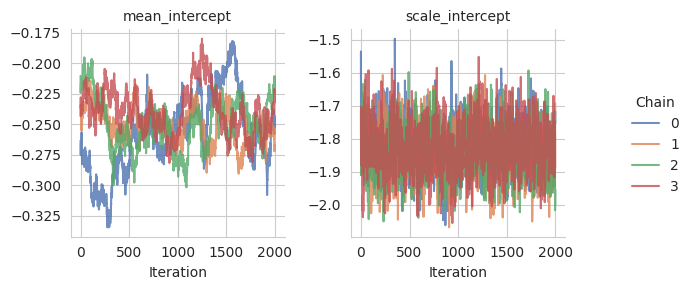

In [11]:
gs.plot_trace(iwls_results, ["mean_intercept", "scale_intercept"])

## NUTS sampler

Keep the same likelihood, priors, parameterization, and exact Gibbs updates
for smoothing variances. Change only the regression coefficient updates to
NUTS: one block for the mean intercept and spline, another for the log standard
deviation intercept and spline. Updating an intercept with its smooth can help
when they are strongly correlated under a heteroscedastic likelihood, even
though the smooth is centered in the observed design.

NUTS learns a step size and full mass matrix for each block during adaptation.
The full matrix accounts for coefficient correlations; a target acceptance
probability of 0.99 asks for more conservative integration steps. Both strategies
still sample smoothing variances on their positive scale using the same Gibbs
conditionals. See {doc}`../../goose-kernels` for kernel grouping.

In [12]:
nuts_model = iwls_model.copy()

for group, names in {
    "mean": [mean_intercept.name, mean_smooth.coef.name],
    "log_scale": [scale_intercept.name, scale_smooth.coef.name],
}.items():
    coefficient_nuts = gs.MCMCSpec(
        gs.NUTSKernel,
        kernel_group=group,
        kernel_kwargs={"mm_diag": False, "da_target_accept": 0.99},
        jitter_dist=coefficient_jitter,
    )
    for name in names:
        nuts_model.vars[name].inference = coefficient_nuts

(transformed-graph)=
The model graph above is unchanged: only the inference specifications differ.
The coefficient blocks now use NUTS and the two variance blocks remain Gibbs.

In [13]:
nuts_results = gs.LieselMCMC(nuts_model).run_for_epochs(
    seed=2027,
    num_chains=4,
    adaptation=1500,
    posterior=2000,
    show_progress=False,
)
nuts_summary = gs.Summary(nuts_results)

liesel.goose.engine - INFO - Initializing kernels...


liesel.goose.engine - INFO - Done


liesel.goose.engine - INFO - Finished warmup


In [14]:
nuts_summary.aggregate_diagnostics().drop(columns="aggregated_by").round(3)

,ess_bulk,ess_tail,rhat
parameter,,,
$\beta_{mean.ps(times)}$,4366.521,4756.968,1.001
$\beta_{scale.ps(times)}$,700.431,1034.882,1.003
$\tau_{mean.ps(times)}^2$,3060.801,4446.303,1.001
$\tau_{scale.ps(times)}^2$,558.995,983.784,1.005
mean_intercept,9644.909,6727.178,1.000
scale_intercept,2286.388,4191.738,1.001


In [15]:
nuts_summary.error_df().reset_index().filter(
    items=["kernel", "error_msg", "phase", "count", "relative"],
)

,kernel,error_msg,phase,count,relative
0,kernel_00,divergent transition,warmup,26,0.004333
1,kernel_00,divergent transition,posterior,0,0.0
2,kernel_00,maximum tree depth,warmup,23,0.003833
3,kernel_00,maximum tree depth,posterior,0,0.0
4,kernel_01,divergent transition,warmup,14,0.002333
5,kernel_01,divergent transition,posterior,0,0.0


The NUTS/Gibbs run has no divergences or trajectory-limit hits in retained
posterior draws. Across all parameter blocks, the largest R-hat is about 1.01
and the smallest bulk ESS is about 606; the smoothing variance for log standard
deviation mixes most slowly. Warmup errors are reported separately. These
checks support using this run for the comparison, while higher-precision tail
estimates would merit longer runs and additional checks.

(nuts-traces)=

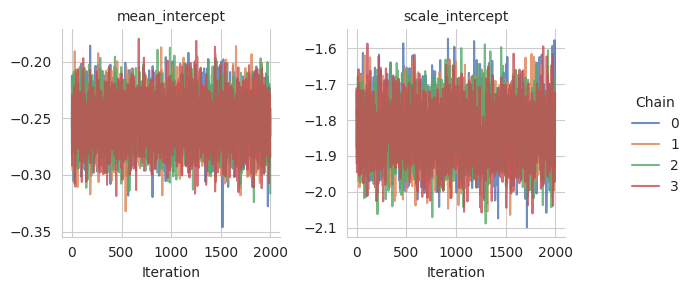

In [16]:
gs.plot_trace(nuts_results, ["mean_intercept", "scale_intercept"])

## Compare shared quantities

Both runs retain 2,000 draws per chain without thinning. The table compares
identical scalar quantities; R-hat and effective sample sizes apply to those
quantities, not to a sampler in general. See {doc}`../../goose-diagnostics` for
interpretation and checks beyond these two intercepts.

In [17]:
intercept_comparison = pd.concat(
    {
        "IWLS/Gibbs": iwls_summary.to_dataframe(),
        "NUTS/Gibbs": nuts_summary.to_dataframe(),
    },
    names=["sampler"],
)
intercept_comparison = intercept_comparison.loc[
    (slice(None), ["mean_intercept", "scale_intercept"]),
    ["mean", "sd", "rhat", "ess_bulk", "ess_tail"],
]

In [18]:
intercept_comparison.round(3)

mean     sd   rhat  ess_bulk  ess_tail
sampler    variable                                                
IWLS/Gibbs mean_intercept  -0.249  0.023  1.165    18.868    20.579
           scale_intercept -1.831  0.073  1.009   754.659  1524.426
NUTS/Gibbs mean_intercept  -0.253  0.020  1.000  9644.909  6727.178
           scale_intercept -1.831  0.074  1.001  2286.388  4191.738

An iteration of NUTS can evaluate the target and its gradient many times.
Higher ESS for equal retained draws therefore does not establish higher
ESS per second. For a runtime comparison, measure both warmup and sampling on
the same hardware and distinguish first-run compilation from subsequent runs.

Next compare both response parameters on their original scales. Transform
`mu` and `sigma` **within each draw**, then summarize. These 90% pointwise
credible bands describe the mean and standard deviation; neither is an
interval for a new acceleration measurement.

In [19]:
time_grid = jnp.linspace(mcycle["times"].min(), mcycle["times"].max(), 120)
curve_summaries = []

for label, fitted_model, results in [
    ("IWLS/Gibbs", iwls_model, iwls_results),
    ("NUTS/Gibbs", nuts_model, nuts_results),
]:
    predicted = fitted_model.predict(
        results.get_posterior_samples(),
        predict=["mu", "sigma"],
        newdata=gs.Position({"times": time_grid}),
    )
    predicted = {name: 100.0 * draws for name, draws in predicted.items()}
    curve = gs.SamplesSummary(predicted).to_dataframe().reset_index()
    curve["times"] = np.tile(np.asarray(time_grid), 2)
    curve["sampler"] = label
    curve_summaries.append(curve)

curves = pd.concat(curve_summaries, ignore_index=True)
curves["quantity"] = curves["variable"].map(
    {"mu": "Mean acceleration (g)", "sigma": "Standard deviation (g)"},
)

(iwls-spline)=
(nuts-spline)=

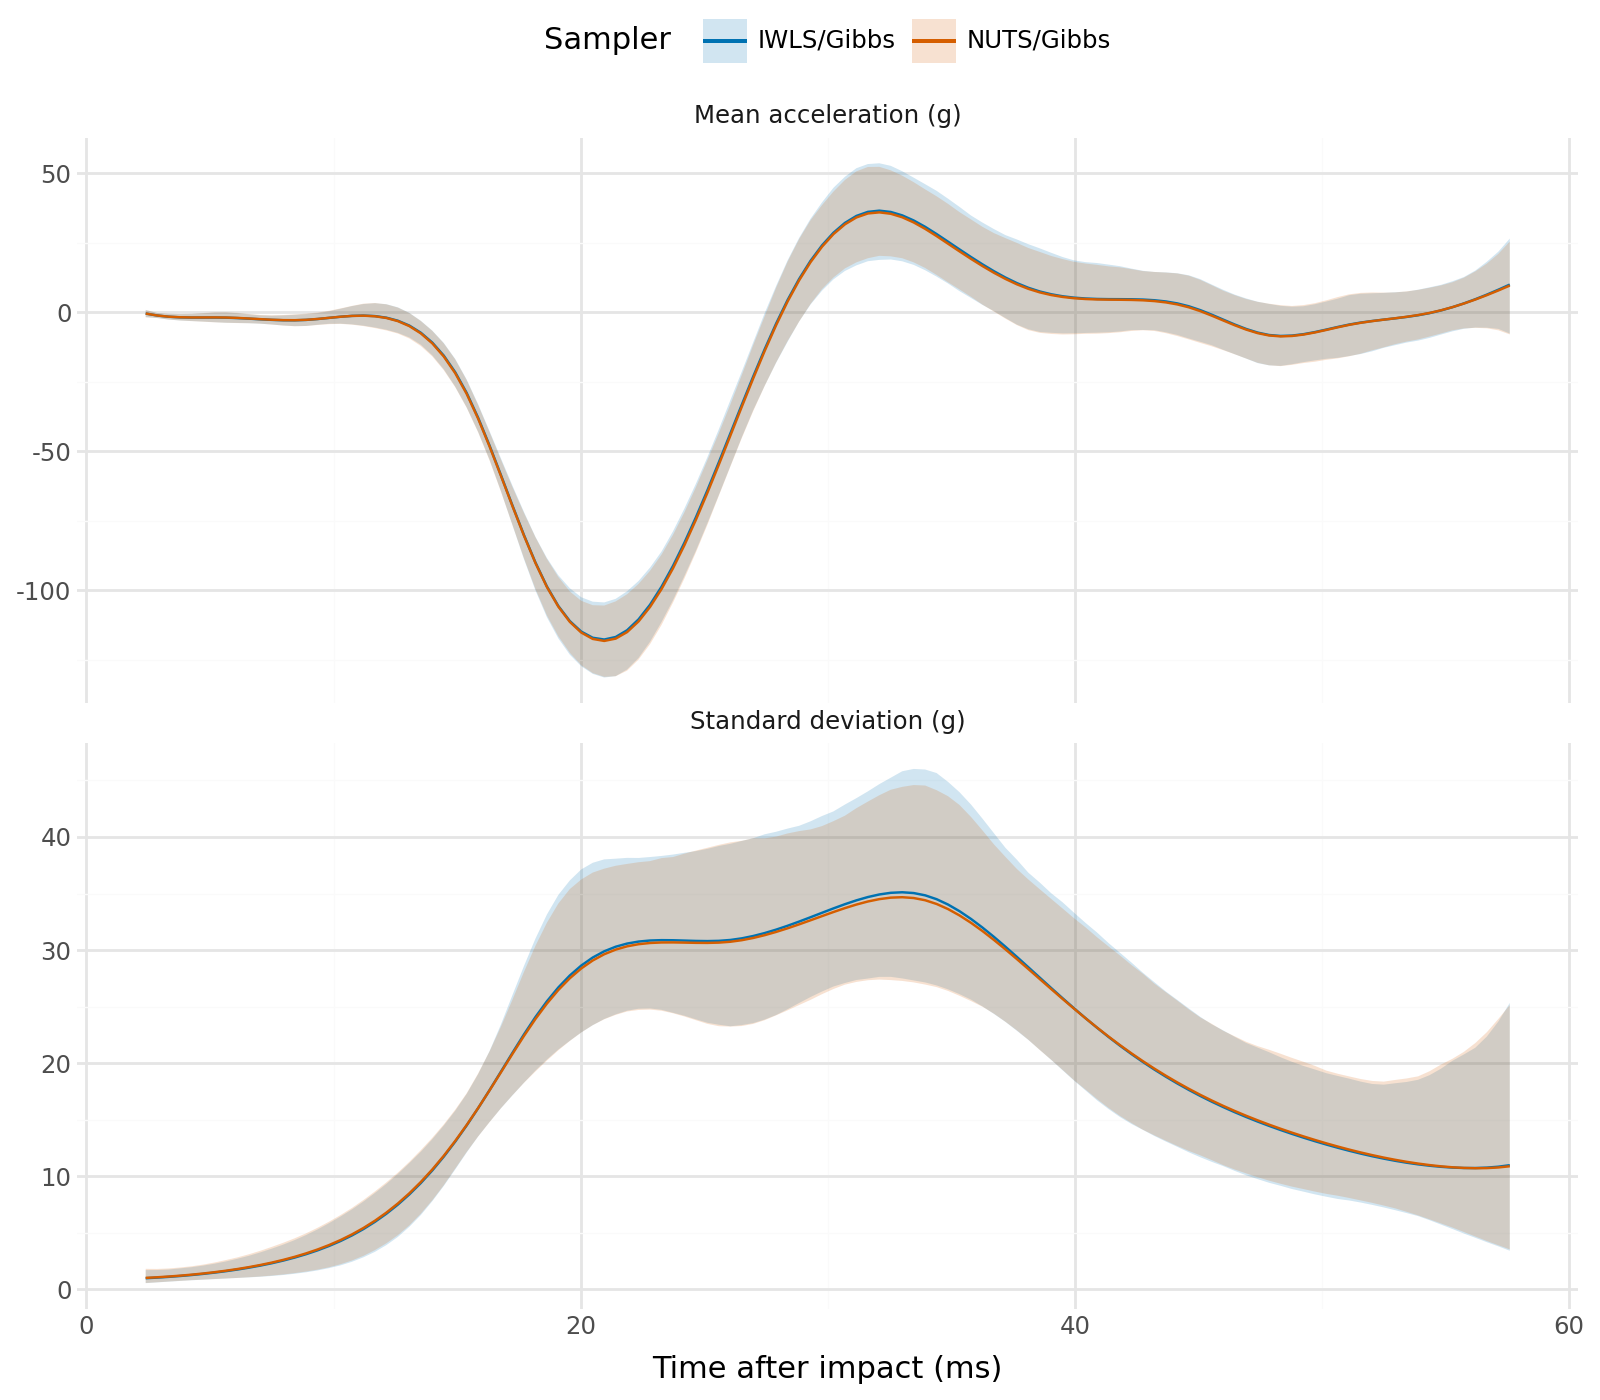

In [20]:
(
    p9.ggplot(curves, p9.aes("times", "mean", color="sampler", fill="sampler"))
    + p9.geom_ribbon(p9.aes(ymin="q_0.05", ymax="q_0.95"), alpha=0.18, color=None)
    + p9.geom_line()
    + p9.facet_wrap("~quantity", scales="free_y", ncol=1)
    + p9.scale_color_manual(values={"IWLS/Gibbs": "#0072B2", "NUTS/Gibbs": "#D55E00"})
    + p9.scale_fill_manual(values={"IWLS/Gibbs": "#0072B2", "NUTS/Gibbs": "#D55E00"})
    + p9.labs(x="Time after impact (ms)", y="", color="Sampler", fill="Sampler")
    + p9.theme_minimal()
    + p9.theme(legend_position="top", figure_size=(8, 7))
)

The curves nearly coincide, but that agreement does not repair the slow IWLS
mean-intercept chain. Use the NUTS/Gibbs run as the better-supported reference
here. Neither a plausible curve nor agreement alone establishes convergence
or validates the Gaussian response assumption. For
predictive model checks, continue to {doc}`../../model-simulation`.